In [1]:
from sklearn.datasets import load_iris
import pandas as pd

# Load dataset
iris = load_iris()

# Convert to DataFrame
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

# Show first 5 rows
print("First 5 rows:\n", X.head())

# Shape of dataset
print("\nShape of dataset:", X.shape)

# Number of classes
print("\nNumber of classes:", len(set(y)))

First 5 rows:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Shape of dataset: (150, 4)

Number of classes: 3


The dataset contains 150 samples with 4 features each. It belongs to 3 different classes. The data is well-structured and suitable for classification tasks.


Data Preprocessing:


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Show sample scaled data
print("\nSample Scaled Data:\n", X_train_scaled[:5])


Sample Scaled Data:
 [[-1.47393679  1.20365799 -1.56253475 -1.31260282]
 [-0.13307079  2.99237573 -1.27600637 -1.04563275]
 [ 1.08589829  0.08570939  0.38585821  0.28921757]
 [-1.23014297  0.75647855 -1.2187007  -1.31260282]
 [-1.7177306   0.30929911 -1.39061772 -1.31260282]]


Feature scaling is important in SVM because it depends on distance between data points. Without scaling, features with larger values dominate the model and reduce accuracy.


Model Training:


In [3]:
from sklearn.svm import SVC

# Linear Kernel
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_scaled, y_train)
print("Linear SVM trained successfully")

# RBF Kernel
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_scaled, y_train)
print("RBF SVM trained successfully")

Linear SVM trained successfully
RBF SVM trained successfully


Model Evaluation:


In [4]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Predictions
y_pred_linear = svm_linear.predict(X_test_scaled)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

# Accuracy
acc_linear = accuracy_score(y_test, y_pred_linear)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

print("\nLinear Kernel Accuracy:", acc_linear)
print("RBF Kernel Accuracy:", acc_rbf)

# Confusion Matrix
cm_linear = confusion_matrix(y_test, y_pred_linear)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

print("\nConfusion Matrix (Linear):\n", cm_linear)
print("\nConfusion Matrix (RBF):\n", cm_rbf)


Linear Kernel Accuracy: 0.9666666666666667
RBF Kernel Accuracy: 1.0

Confusion Matrix (Linear):
 [[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]

Confusion Matrix (RBF):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


The RBF kernel usually performs better because it can handle non-linear data, while the linear kernel works best for linearly separable data.


Visualization:


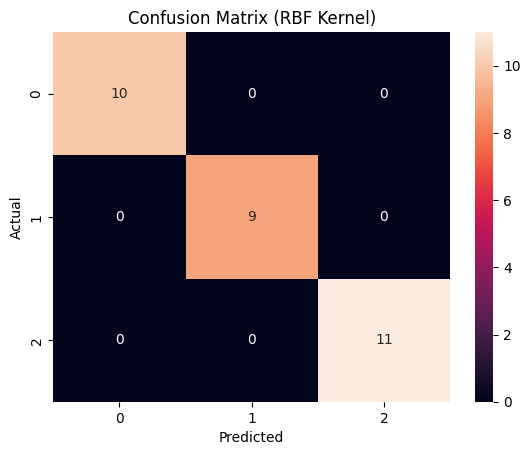

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(cm_rbf, annot=True, fmt='d')
plt.title("Confusion Matrix (RBF Kernel)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Aalysis & Conclusion:

1. Which kernel performed better? Why?

The RBF kernel performed better because it can model non-linear relationships, making it more flexible than the linear kernel.

2. How does scaling affect SVM performance?

Scaling ensures all features contribute equally. Without scaling, features with larger ranges dominate and reduce model accuracy.

3. What challenges did you face?

Understanding kernel selection and applying feature scaling correctly were the main challenges.
